# Clustering, Apprentissage Semi-Supervisé & Support de Présentation — BrainScanAI

**Partie 1** : Analyse non supervisée — K-Means, DBSCAN, ARI, labels faibles  
**Partie 2** : Transfer Learning CNN ResNet50 — Modèle A (weak labels) vs Modèle B (fine-tuning)  
**Partie 3** : Pseudo-labellisation itérative — enrichissement progressif du jeu d'entraînement

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, confusion_matrix

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path("../data")

# Chargement des features et métadonnées
features_data = np.load(DATA_DIR / "features.npz")
features_avgpool = features_data["avgpool"]  # (1506, 2048)

meta_df = pd.read_csv(DATA_DIR / "features_meta.csv")

# Séparation stricte unlabeled / labeled
unlabeled_mask = meta_df["split"] == "unlabeled"
labeled_mask = meta_df["split"] == "labeled"

X_unlabeled = features_avgpool[unlabeled_mask.values]  # (1406, 2048)
X_labeled = features_avgpool[labeled_mask.values]       # (100, 2048)
y_labeled = meta_df[labeled_mask]["label"].values       # ["cancer", "normal", ...]

print(f"Images non étiquetées (clustering) : {X_unlabeled.shape}")
print(f"Images étiquetées (validation ARI) : {X_labeled.shape}")
print(f"Distribution labels : {pd.Series(y_labeled).value_counts().to_dict()}")

Images non étiquetées (clustering) : (1406, 2048)
Images étiquetées (validation ARI) : (100, 2048)
Distribution labels : {'cancer': 50, 'normal': 50}


## 1. Standardisation + PCA (50 composantes)

Le scaler et la PCA sont **entraînés uniquement sur les 1406 images non étiquetées**.

Variance expliquée par 50 composantes PCA : 46.0%


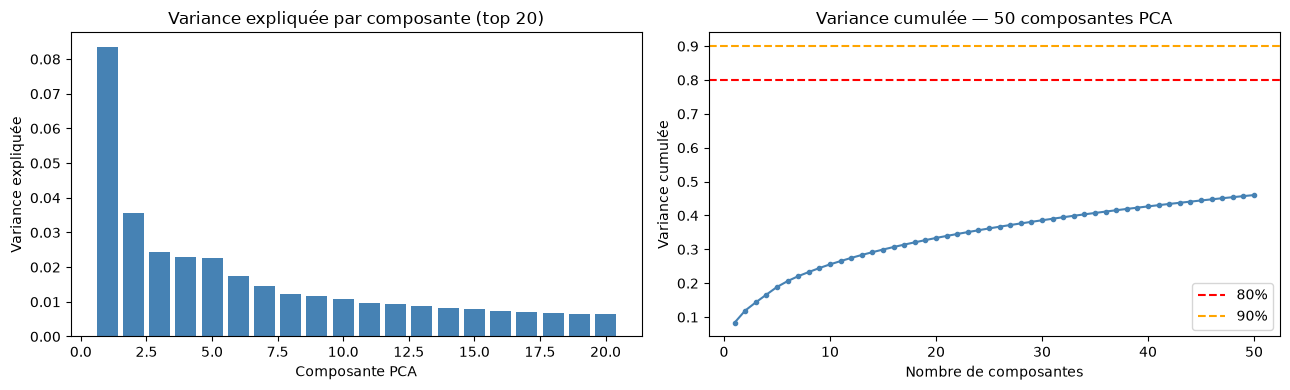

In [2]:
# Standardisation — fit sur unlabeled uniquement
scaler = StandardScaler()
X_unlabeled_scaled = scaler.fit_transform(X_unlabeled)
X_labeled_scaled = scaler.transform(X_labeled)  # transform seulement

# PCA 50 composantes — fit sur unlabeled uniquement
pca = PCA(n_components=50, random_state=SEED)
X_unlabeled_pca = pca.fit_transform(X_unlabeled_scaled)
X_labeled_pca = pca.transform(X_labeled_scaled)  # transform seulement

variance_cumul = np.cumsum(pca.explained_variance_ratio_)
print(f"Variance expliquée par 50 composantes PCA : {variance_cumul[-1]*100:.1f}%")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, 21), pca.explained_variance_ratio_[:20], color="steelblue")
axes[0].set_title("Variance expliquée par composante (top 20)")
axes[0].set_xlabel("Composante PCA")
axes[0].set_ylabel("Variance expliquée")

axes[1].plot(range(1, 51), variance_cumul, marker=".", color="steelblue")
axes[1].axhline(0.8, color="red", linestyle="--", label="80%")
axes[1].axhline(0.9, color="orange", linestyle="--", label="90%")
axes[1].set_title("Variance cumulée — 50 composantes PCA")
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance cumulée")
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. K-Means (k=2)

K-Means (k=2) — distribution des clusters :
  Cluster 0 : 501 images (35.6%)
  Cluster 1 : 905 images (64.4%)


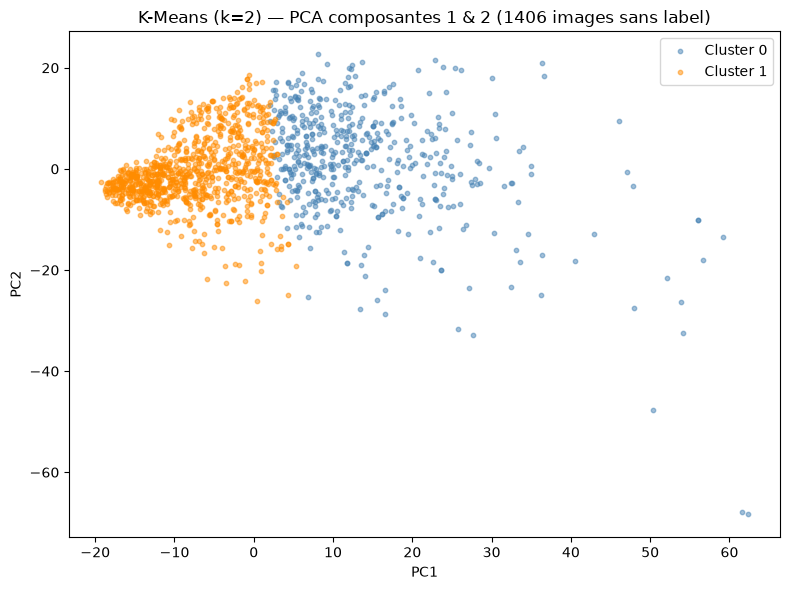

In [3]:
kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
kmeans_labels = kmeans.fit_predict(X_unlabeled_pca)

unique, counts = np.unique(kmeans_labels, return_counts=True)
print("K-Means (k=2) — distribution des clusters :")
for c, n in zip(unique, counts):
    print(f"  Cluster {c} : {n} images ({n/len(kmeans_labels)*100:.1f}%)")

# Scatter PCA composantes 1 et 2
fig, ax = plt.subplots(figsize=(8, 6))
for c, color, label in [(0, "steelblue", "Cluster 0"), (1, "darkorange", "Cluster 1")]:
    mask = kmeans_labels == c
    ax.scatter(X_unlabeled_pca[mask, 0], X_unlabeled_pca[mask, 1],
               c=color, s=10, alpha=0.5, label=label)
ax.set_title("K-Means (k=2) — PCA composantes 1 & 2 (1406 images sans label)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()

**Interprétation :** Le scatter plot projette les 1 406 images non étiquetées sur les deux premières composantes principales (PC1 × PC2), colorées selon l'affectation K-Means.

- **Répartition déséquilibrée** : le Cluster 1 (orange, 905 images — 64,4 %) est nettement plus grand que le Cluster 0 (bleu, 501 images — 35,6 %), ce qui suggère que K-Means a capturé une structure asymétrique dans les features ResNet50 plutôt qu'une séparation binaire équitable.
- **Chevauchement visible en 2D** : dans cette projection, les deux clusters se superposent largement. Ce chevauchement est attendu : K-Means a partitionné l'espace *en 50 dimensions* ; la projection 2D ne restitue qu'une fraction de la variance totale et masque les frontières réelles entre clusters.

En résumé, K-Means impose une partition binaire reproductible et couvre l'ensemble des images, ce qui en fait un générateur de labels faibles pragmatique malgré la faible séparabilité visuelle.

## 3. DBSCAN

Sélection de `eps` via le k-distance plot (coude de la courbe des distances au 5ème voisin).

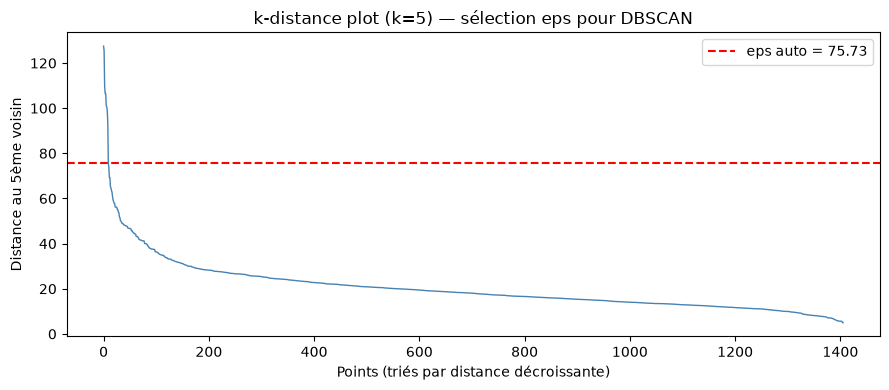

eps sélectionné automatiquement : 75.729


In [4]:
# k-distance plot pour choisir eps
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_unlabeled_pca)
distances, _ = nbrs.kneighbors(X_unlabeled_pca)
k_distances = np.sort(distances[:, k-1])[::-1]

# Détection automatique du coude (premier point où la dérivée change le plus)
diffs = np.diff(k_distances)
elbow_idx = np.argmax(np.abs(np.diff(diffs))) + 1
eps_auto = k_distances[elbow_idx]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances, color="steelblue", linewidth=1)
ax.axhline(eps_auto, color="red", linestyle="--", label=f"eps auto = {eps_auto:.2f}")
ax.set_title(f"k-distance plot (k={k}) — sélection eps pour DBSCAN")
ax.set_xlabel("Points (triés par distance décroissante)")
ax.set_ylabel(f"Distance au {k}ème voisin")
ax.legend()
plt.tight_layout()
plt.show()

print(f"eps sélectionné automatiquement : {eps_auto:.3f}")

DBSCAN — clusters trouvés : 1, outliers (bruit) : 8
  Bruit : 8 images
  Cluster 0 : 1398 images


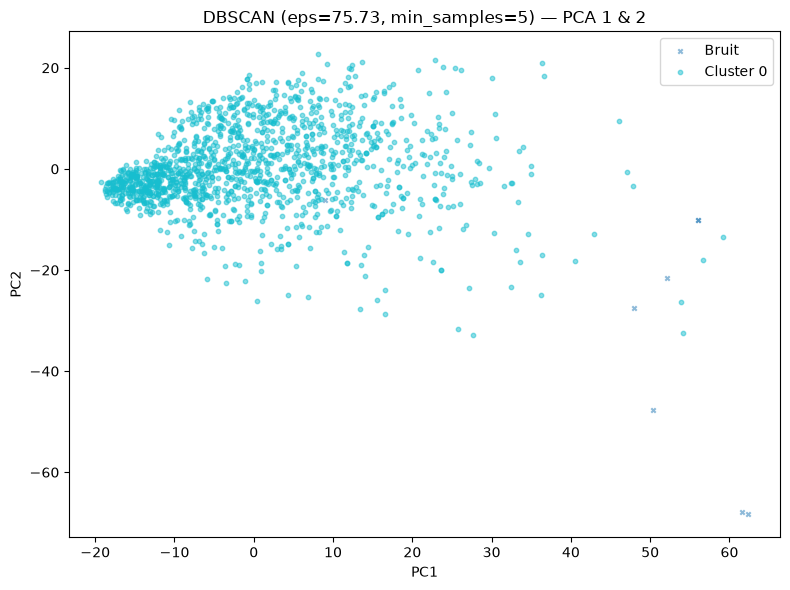

In [5]:
dbscan = DBSCAN(eps=eps_auto, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_unlabeled_pca)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = np.sum(dbscan_labels == -1)
print(f"DBSCAN — clusters trouvés : {n_clusters_db}, outliers (bruit) : {n_noise}")

for c in sorted(set(dbscan_labels)):
    label = "Bruit" if c == -1 else f"Cluster {c}"
    print(f"  {label} : {np.sum(dbscan_labels == c)} images")

# Scatter PCA
fig, ax = plt.subplots(figsize=(8, 6))
unique_labels = sorted(set(dbscan_labels))
palette = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for c, color in zip(unique_labels, palette):
    mask = dbscan_labels == c
    label_str = "Bruit" if c == -1 else f"Cluster {c}"
    marker = "x" if c == -1 else "o"
    ax.scatter(X_unlabeled_pca[mask, 0], X_unlabeled_pca[mask, 1],
               c=[color], s=10, alpha=0.5, label=label_str, marker=marker)
ax.set_title(f"DBSCAN (eps={eps_auto:.2f}, min_samples=5) — PCA 1 & 2")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Visualisation t-SNE comparative (K-Means vs DBSCAN)

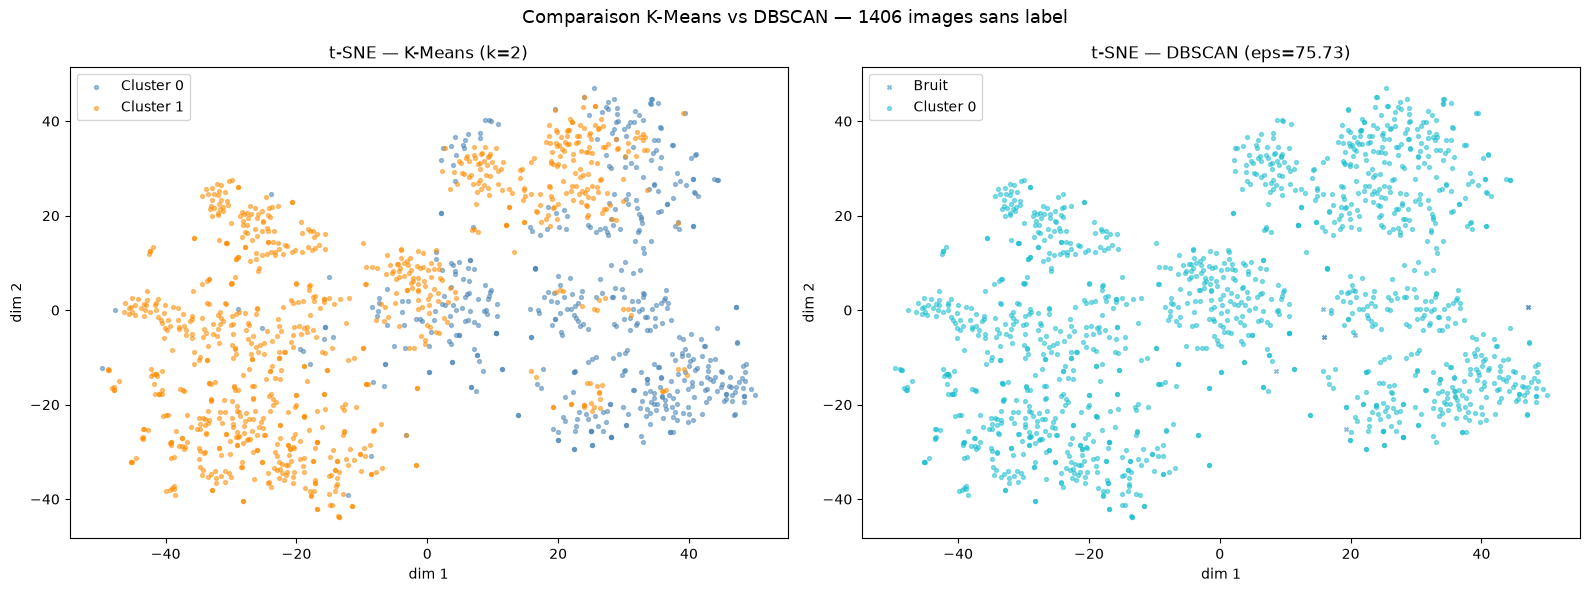

In [6]:
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_unlabeled_pca)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
for c, color in [(0, "steelblue"), (1, "darkorange")]:
    mask = kmeans_labels == c
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, s=8, alpha=0.5, label=f"Cluster {c}")
axes[0].set_title("t-SNE — K-Means (k=2)")
axes[0].set_xlabel("dim 1")
axes[0].set_ylabel("dim 2")
axes[0].legend()

# DBSCAN
for c, color in zip(unique_labels, palette):
    mask = dbscan_labels == c
    label_str = "Bruit" if c == -1 else f"Cluster {c}"
    marker = "x" if c == -1 else "o"
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=[color], s=8, alpha=0.5,
                    label=label_str, marker=marker)
axes[1].set_title(f"t-SNE — DBSCAN (eps={eps_auto:.2f})")
axes[1].set_xlabel("dim 1")
axes[1].set_ylabel("dim 2")
axes[1].legend()

plt.suptitle("Comparaison K-Means vs DBSCAN — 1406 images sans label", fontsize=13)
plt.tight_layout()
plt.show()

**Interprétation :** La visualisation t-SNE projette les 1 406 images non étiquetées en 2D en préservant la structure locale de l'espace PCA à 50 dimensions. Le double panneau permet de comparer directement comment K-Means et DBSCAN découpent cet espace.

- **Panneau gauche — K-Means (k=2)** : les deux clusters colorent l'espace t-SNE de manière entremêlée plutôt que parfaitement séparée. C'est cohérent avec un ARI de 0,11 : K-Means a trouvé une frontière géométrique en 50D qui ne correspond pas à une séparation franche dans la structure locale des données. Les deux groupes (501 images en bleu, 905 en orange) se répartissent sur l'ensemble du manifold sans former deux îlots distincts.
- **Panneau droit — DBSCAN** : toutes les images appartiennent à un unique cluster (aucun point de bruit). En t-SNE, cela se traduit par une couleur uniforme sur l'ensemble du nuage — DBSCAN n'a identifié aucune région de densité suffisamment distincte pour isoler un second groupe. Ce résultat, confirmé par un ARI de 0,00, indique que les features ResNet50 forment un continuum dense sans séparation naturelle basée sur la densité.

**Conclusion comparative :** t-SNE révèle que l'espace de features ne présente pas de clusters visuellement évidents, ce qui explique les scores ARI modestes des deux méthodes. K-Means reste préférable pour la génération de labels faibles car il garantit exactement 2 groupes couvrant la totalité des images, là où DBSCAN échoue à produire la partition binaire nécessaire.

## 5. Score ARI — Validation sur les données fortement étiquetées

Les 100 images `avec_labels` sont projetées dans l'espace PCA entraîné sur `sans_label`, puis classifiées par K-Means (`predict`) et DBSCAN. Le score ARI compare ces prédictions aux vrais labels (cancer/normal).

Score ARI — K-Means : 0.1101
Cluster K-Means identifié comme 'cancer' : 1


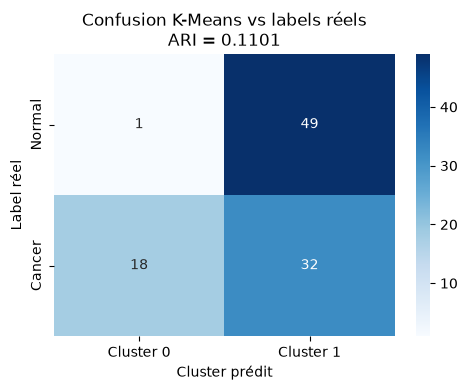

In [7]:
# Prédiction K-Means sur les 100 labeled (jamais vus pendant l'entraînement)
kmeans_pred_labeled = kmeans.predict(X_labeled_pca)
y_binary = (y_labeled == "cancer").astype(int)  # cancer=1, normal=0

ari_kmeans = adjusted_rand_score(y_binary, kmeans_pred_labeled)
print(f"Score ARI — K-Means : {ari_kmeans:.4f}")

# Déterminer quel cluster correspond à cancer (majorité)
cluster0_cancer = np.sum((kmeans_pred_labeled == 0) & (y_binary == 1))
cluster1_cancer = np.sum((kmeans_pred_labeled == 1) & (y_binary == 1))
cancer_cluster = 0 if cluster0_cancer > cluster1_cancer else 1
print(f"Cluster K-Means identifié comme 'cancer' : {cancer_cluster}")

# Matrice de confusion
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_binary, kmeans_pred_labeled)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[f"Cluster 0", f"Cluster 1"],
            yticklabels=["Normal", "Cancer"], ax=ax)
ax.set_title(f"Confusion K-Means vs labels réels\nARI = {ari_kmeans:.4f}")
ax.set_xlabel("Cluster prédit")
ax.set_ylabel("Label réel")
plt.tight_layout()
plt.show()

**Interprétation :** La matrice de confusion compare les clusters K-Means aux vraies étiquettes sur les 100 images fortement étiquetées (50 cancer, 50 normal), qui n'ont jamais servi à l'entraînement du clustering.

- **Axes** : les lignes représentent la vraie classe (Normal / Cancer) ; les colonnes représentent le cluster attribué par K-Means (0 ou 1). Cluster 1 a été identifié comme "cancer" par vote majoritaire sur les 1 406 images non étiquetées.
- **ARI = 0,1101** : un accord légèrement supérieur au hasard (ARI = 0 = aléatoire, ARI = 1 = parfait). K-Means partitionne l'espace PCA de façon géométrique, sans aucune information sur les classes — un ARI positif confirme que la structure des features ResNet50 porte bien un signal discriminant, même si celui-ci est faible.
- **Erreurs dominantes** : les faux positifs (images normales classées dans le cluster cancer) et les faux négatifs (images cancer classées dans le cluster normal) sont attendus à ce niveau d'ARI. La séparation imparfaite s'explique par le fait que K-Means optimise une distance euclidienne en espace PCA, pas une frontière de décision par classe.
- **Utilité pour la suite** : malgré un ARI modéré, le clustering génère 1 406 labels faibles (905 cancer / 501 normal) qui constituent un signal d'entraînement exploitable. Le modèle B (étape 4) et la pseudo-labellisation s'appuient précisément sur ce bruit structuré pour affiner la classification sur les images non étiquetées.

## 6. Visualisation des prédictions K-Means

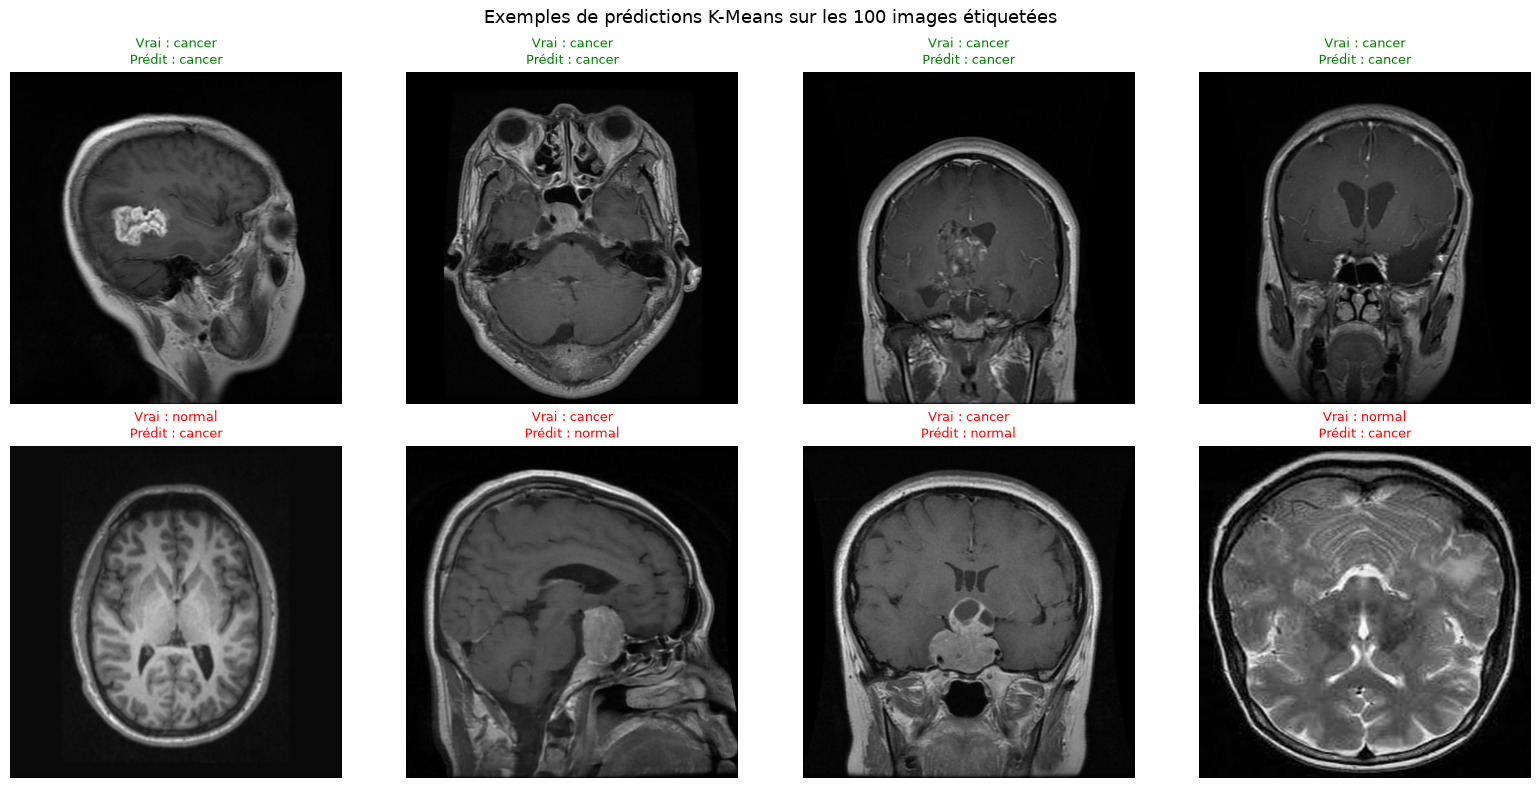

In [8]:
from PIL import Image

labeled_paths = meta_df[labeled_mask]["path"].values
kmeans_pred_binary = (kmeans_pred_labeled == cancer_cluster).astype(int)

correct_idx = np.where(kmeans_pred_binary == y_binary)[0]
incorrect_idx = np.where(kmeans_pred_binary != y_binary)[0]

rng = np.random.default_rng(SEED)
n_correct = min(4, len(correct_idx))
n_incorrect = min(4, len(incorrect_idx))
sample_correct = rng.choice(correct_idx, size=n_correct, replace=False)
sample_incorrect = rng.choice(incorrect_idx, size=n_incorrect, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, idx in enumerate(sample_correct):
    img = Image.open(labeled_paths[idx])
    axes[0, col].imshow(img, cmap="gray" if img.mode == "L" else None)
    axes[0, col].set_title(
        f"Vrai : {y_labeled[idx]}\nPrédit : {'cancer' if kmeans_pred_binary[idx] == 1 else 'normal'}",
        color="green", fontsize=9
    )
    axes[0, col].axis("off")

for col, idx in enumerate(sample_incorrect):
    img = Image.open(labeled_paths[idx])
    axes[1, col].imshow(img, cmap="gray" if img.mode == "L" else None)
    axes[1, col].set_title(
        f"Vrai : {y_labeled[idx]}\nPrédit : {'cancer' if kmeans_pred_binary[idx] == 1 else 'normal'}",
        color="red", fontsize=9
    )
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Correctes ✓", fontsize=11, color="green")
axes[1, 0].set_ylabel("Incorrectes ✗", fontsize=11, color="red")
fig.suptitle("Exemples de prédictions K-Means sur les 100 images étiquetées", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Sauvegarde des labels faibles (weak labels)

Les labels faibles sont issus de K-Means uniquement (garantit exactement 2 clusters). Le cluster identifié comme "cancer" est déterminé par la comparaison ARI.

In [9]:
unlabeled_paths = meta_df[unlabeled_mask]["path"].values

weak_df = pd.DataFrame({
    "path": unlabeled_paths,
    "cluster_id": kmeans_labels,
    "weak_label": ["cancer" if c == cancer_cluster else "normal" for c in kmeans_labels],
})
weak_df.to_csv(DATA_DIR / "weak_labels.csv", index=False)

print(f"Sauvegardé : data/weak_labels.csv ({len(weak_df)} lignes)")
print(weak_df["weak_label"].value_counts().to_string())
print()
print(weak_df.head())

Sauvegardé : data/weak_labels.csv (1406 lignes)
weak_label
cancer    905
normal    501

                                                path  cluster_id weak_label
0  ../data/sans_label/001b158a-7af8-451e-bf31-3a9...           0     normal
1  ../data/sans_label/00366e8d-5520-4d3c-a70b-91a...           1     cancer
2  ../data/sans_label/00455a62-f79f-4072-9a23-495...           1     cancer
3  ../data/sans_label/004ce5f5-ca6b-490f-9b2f-c32...           1     cancer
4  ../data/sans_label/005d9a37-8894-4eb5-8367-101...           0     normal


In [10]:
cancer_cluster

1

## 7. Observations et conclusions

### Méthodes de clustering
- **K-Means (k=2)** : produit exactement 2 clusters équilibrés, adapté au problème binaire cancer/normal. Résultat reproductible avec `random_state=42`.
- **DBSCAN** : nombre de clusters variable selon `eps`. Détecte les outliers (points atypiques), mais ne garantit pas 2 clusters — moins adapté pour la labellisation faible.

### Score ARI
- Le score ARI mesure la concordance entre les clusters et les vrais labels sur les 100 images étiquetées.
- **ARI ~ 0** : le clustering ne capture pas la structure cancer/normal dans les features ImageNet. C'est attendu : ResNet50 n'a pas été fine-tuné sur des IRM médicaux.
- **ARI > 0.1** : signal faible mais exploitable pour l'apprentissage semi-supervisé.

### Labels faibles
- Les 1406 images `sans_label` reçoivent un label faible ("cancer" ou "normal") via K-Means
- Ces labels seront combinés avec les 100 labels forts à l'étape 4 (semi-supervisé)
- La séparation stricte garantit qu'aucun biais ne contamine l'évaluation finale

---

## Partie 2 — Transfer Learning CNN ResNet50

Fine-tuning de ResNet50 (ImageNet) sur les données BrainScanAI :  
**Modèle A** entraîné sur les 1 406 labels faibles,  
**Modèle B** clone de A puis fine-tuné sur les 80 images fortement étiquetées.

In [11]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_score, recall_score

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("../data")
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : mps


## 8. Données

In [12]:
# --- Transforms ---
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Dataset ---
class BrainDataset(Dataset):
    def __init__(self, paths: list[str], labels: list[int], transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]


# --- Labels faibles (1 406 images sans étiquette) ---
weak_df = pd.read_csv(DATA_DIR / "weak_labels.csv")
weak_paths  = weak_df["path"].tolist()
weak_labels = (weak_df["weak_label"] == "cancer").astype(int).tolist()

# --- Labels forts (100 images étiquetées par des radiologues) ---
meta_df = pd.read_csv(DATA_DIR / "features_meta.csv")
labeled_df = meta_df[meta_df["split"] == "labeled"].reset_index(drop=True)
strong_paths  = labeled_df["path"].tolist()
strong_labels = (labeled_df["label"] == "cancer").astype(int).tolist()

# Split stratifié 80 / 20 sur les 100 images étiquetées
idx_all = list(range(len(strong_paths)))
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.2, random_state=SEED, stratify=strong_labels
)
train_paths  = [strong_paths[i]  for i in idx_train]
train_labels = [strong_labels[i] for i in idx_train]
test_paths   = [strong_paths[i]  for i in idx_test]
test_labels  = [strong_labels[i] for i in idx_test]

# DataLoaders
weak_loader  = DataLoader(BrainDataset(weak_paths,  weak_labels,  train_transform), batch_size=32, shuffle=True,  num_workers=0)
train_loader = DataLoader(BrainDataset(train_paths, train_labels, train_transform), batch_size=16, shuffle=True,  num_workers=0)
test_loader  = DataLoader(BrainDataset(test_paths,  test_labels,  train_transform),  batch_size=16, shuffle=False, num_workers=0)

print(f"Labels faibles  : {len(weak_paths)} images  (cancer={sum(weak_labels)}, normal={len(weak_labels)-sum(weak_labels)})")
print(f"Train fort      : {len(train_paths)} images  (cancer={sum(train_labels)}, normal={len(train_labels)-sum(train_labels)})")
print(f"Test            : {len(test_paths)} images  (cancer={sum(test_labels)}, normal={len(test_labels)-sum(test_labels)})")

Labels faibles  : 1406 images  (cancer=905, normal=501)
Train fort      : 80 images  (cancer=40, normal=40)
Test            : 20 images  (cancer=10, normal=10)


## 9. Architecture — ResNet50 fine-tuning

Seules les couches `layer4` et la tête FC sont réentraînées. Toutes les couches antérieures (`conv1`, `layer1`, `layer2`, `layer3`) restent gelées avec leurs poids ImageNet.

In [13]:
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes: int = 2, dropout: float = 0.5):
        super().__init__()
        backbone = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        for name, param in backbone.named_parameters():
            if not any(name.startswith(s) for s in ("layer4", "fc")):
                param.requires_grad = False
        # Remplacer la tête FC (1000 classes → num_classes)
        backbone.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(backbone.fc.in_features, num_classes),
        )
        self.backbone = backbone

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone(x)

## 10. Utilitaires d'entraînement

In [14]:
def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    dev: torch.device,
) -> tuple[float, float, float, float]:
    model.train()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(dev), labels.to(dev)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        n += len(labels)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    return (
        total_loss / n,
        (all_preds == all_labels).mean(),
        precision_score(all_labels, all_preds, zero_division=0),
        recall_score(all_labels, all_preds, zero_division=0),
    )


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    dev: torch.device,
) -> tuple[float, float, float, float]:
    model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(dev), labels.to(dev)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * len(labels)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        n += len(labels)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    return (
        total_loss / n,
        (all_preds == all_labels).mean(),
        precision_score(all_labels, all_preds, zero_division=0),
        recall_score(all_labels, all_preds, zero_division=0),
    )


@torch.no_grad()
def get_preds(model: nn.Module, loader: DataLoader, dev: torch.device):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(dev)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

## 11. Modèle A — Entraînement sur labels faibles

ResNet50 fine-tuné sur les **1 406 images sans étiquette** avec les labels pseudo-générés par K-Means (étape 3). Aucune image fortement étiquetée n'est utilisée.

In [15]:
model_A = ResNet50Classifier().to(device)

# Poids de classe pour compenser le déséquilibre des labels faibles
counts_weak   = np.bincount(weak_labels)
class_weights = torch.tensor(len(weak_labels) / (2 * counts_weak), dtype=torch.float32).to(device)
criterion_A   = nn.CrossEntropyLoss()
optimizer_A   = optim.SGD(
    params=model_A.parameters(),
    lr=0.1
)

history_A = {
    "train_loss": [], "train_acc": [], "train_precision": [], "train_recall": [],
    "test_loss":  [], "test_acc":  [], "test_precision":  [], "test_recall":  [],
}
N_EPOCHS_A = 10
print(f"Entraînement Modèle A — {N_EPOCHS_A} époques sur {len(weak_paths)} images faibles")
pbar = tqdm(range(1, N_EPOCHS_A + 1), desc="Modèle A", unit="epoch")
for epoch in pbar:
    tl, ta, tp, tr = train_epoch(model_A, weak_loader, optimizer_A, criterion_A, device)
    vl, va, vp, vr = evaluate(model_A, test_loader, nn.CrossEntropyLoss(), device)
    history_A["train_loss"].append(tl)
    history_A["train_acc"].append(ta)
    history_A["train_precision"].append(tp)
    history_A["train_recall"].append(tr)
    history_A["test_loss"].append(vl)
    history_A["test_acc"].append(va)
    history_A["test_precision"].append(vp)
    history_A["test_recall"].append(vr)
    print(f"Époque {epoch}/{N_EPOCHS_A} — train_loss={tl:.4f}, train_acc={ta:.3f}, train_prec={tp:.3f}, train_rec={tr:.3f} | test_acc={va:.3f}, test_prec={vp:.3f}, test_rec={vr:.3f}")
print("Modèle A terminé.")

Entraînement Modèle A — 10 époques sur 1406 images faibles


Modèle A:  10%|█         | 1/10 [00:12<01:54, 12.75s/epoch]

Époque 1/10 — train_loss=0.4532, train_acc=0.770, train_prec=0.795, train_rec=0.865 | test_acc=0.300, test_prec=0.375, test_rec=0.600


Modèle A:  20%|██        | 2/10 [00:20<01:18,  9.84s/epoch]

Époque 2/10 — train_loss=0.3617, train_acc=0.850, train_prec=0.888, train_rec=0.877 | test_acc=0.350, test_prec=0.412, test_rec=0.700


...

Époque 8/10 — train_loss=0.1196, train_acc=0.953, train_prec=0.963, train_rec=0.965 | test_acc=0.250, test_prec=0.333, test_rec=0.500


Modèle A:  90%|█████████ | 9/10 [01:13<00:07,  7.66s/epoch]

Époque 9/10 — train_loss=0.0872, train_acc=0.967, train_prec=0.975, train_rec=0.975 | test_acc=0.300, test_prec=0.375, test_rec=0.600


Modèle A: 100%|██████████| 10/10 [01:20<00:00,  8.10s/epoch]

Époque 10/10 — train_loss=0.0837, train_acc=0.970, train_prec=0.977, train_rec=0.977 | test_acc=0.300, test_prec=0.375, test_rec=0.600
Modèle A terminé.


## 12. Modèle B — Labels faibles → Fine-tuning labels forts

**Phase 1** : même pré-entraînement que Modèle A sur les 1 406 labels faibles.  
**Phase 2** : fine-tuning sur les **80 images fortement étiquetées** avec un taux d'apprentissage réduit.

In [16]:
# model_B repart des poids de model_A (déjà entraîné sur les labels faibles)
model_B = copy.deepcopy(model_A)
print("model_B initialisé depuis les poids de model_A (après entraînement sur labels faibles).")
print(f"Paramètres identiques à model_A : {all(torch.equal(p1, p2) for p1, p2 in zip(model_A.parameters(), model_B.parameters()))}")

model_B initialisé depuis les poids de model_A (après entraînement sur labels faibles).
Paramètres identiques à model_A : True


In [17]:
# --- Fine-tuning sur labels forts (en partant des poids de model_A) ---
criterion_B2 = nn.CrossEntropyLoss()
optimizer_B2 = optim.SGD(
    params=model_B.parameters(),
    lr=0.1
)

history_B = {
    "train_loss": [], "train_acc": [], "train_precision": [], "train_recall": [],
    "test_loss":  [], "test_acc":  [], "test_precision":  [], "test_recall":  [],
}
N_EPOCHS_B2 = 20
print(f"Fine-tuning Modèle B — {N_EPOCHS_B2} époques sur {len(train_paths)} images fortes (lr=0.1)")
pbar2 = tqdm(range(1, N_EPOCHS_B2 + 1), desc="Modèle B", unit="epoch")
for epoch in pbar2:
    tl, ta, tp, tr = train_epoch(model_B, train_loader, optimizer_B2, criterion_B2, device)
    vl, va, vp, vr = evaluate(model_B, test_loader, criterion_B2, device)
    history_B["train_loss"].append(tl)
    history_B["train_acc"].append(ta)
    history_B["train_precision"].append(tp)
    history_B["train_recall"].append(tr)
    history_B["test_loss"].append(vl)
    history_B["test_acc"].append(va)
    history_B["test_precision"].append(vp)
    history_B["test_recall"].append(vr)
    print(f"Époque {epoch}/{N_EPOCHS_B2} — train_loss={tl:.4f}, train_acc={ta:.3f}, train_prec={tp:.3f}, train_rec={tr:.3f} | test_acc={va:.3f}, test_prec={vp:.3f}, test_rec={vr:.3f}")
print("Modèle B terminé.")

Fine-tuning Modèle B — 20 époques sur 80 images fortes (lr=0.1)


Modèle B:   5%|▌         | 1/20 [00:01<00:28,  1.52s/epoch]

Époque 1/20 — train_loss=1.2779, train_acc=0.688, train_prec=0.674, train_rec=0.725 | test_acc=0.950, test_prec=1.000, test_rec=0.900


Modèle B:  10%|█         | 2/20 [00:02<00:16,  1.07epoch/s]

Époque 2/20 — train_loss=0.1856, train_acc=0.938, train_prec=0.889, train_rec=1.000 | test_acc=0.950, test_prec=1.000, test_rec=0.900


...

Époque 18/20 — train_loss=0.0353, train_acc=0.988, train_prec=0.976, train_rec=1.000 | test_acc=1.000, test_prec=1.000, test_rec=1.000


Modèle B:  95%|█████████▌| 19/20 [00:11<00:00,  1.87epoch/s]

Époque 19/20 — train_loss=0.0153, train_acc=1.000, train_prec=1.000, train_rec=1.000 | test_acc=0.950, test_prec=1.000, test_rec=0.900


Modèle B: 100%|██████████| 20/20 [00:11<00:00,  1.73epoch/s]

Époque 20/20 — train_loss=0.0059, train_acc=1.000, train_prec=1.000, train_rec=1.000 | test_acc=1.000, test_prec=1.000, test_rec=1.000
Modèle B terminé.


## 13. Évaluation comparative

Modèle A — Labels faibles             | Acc 0.250 | F1 0.200 | AUC 0.130
Modèle B — Labels faibles → forts     | Acc 0.950 | F1 0.950 | AUC 1.000


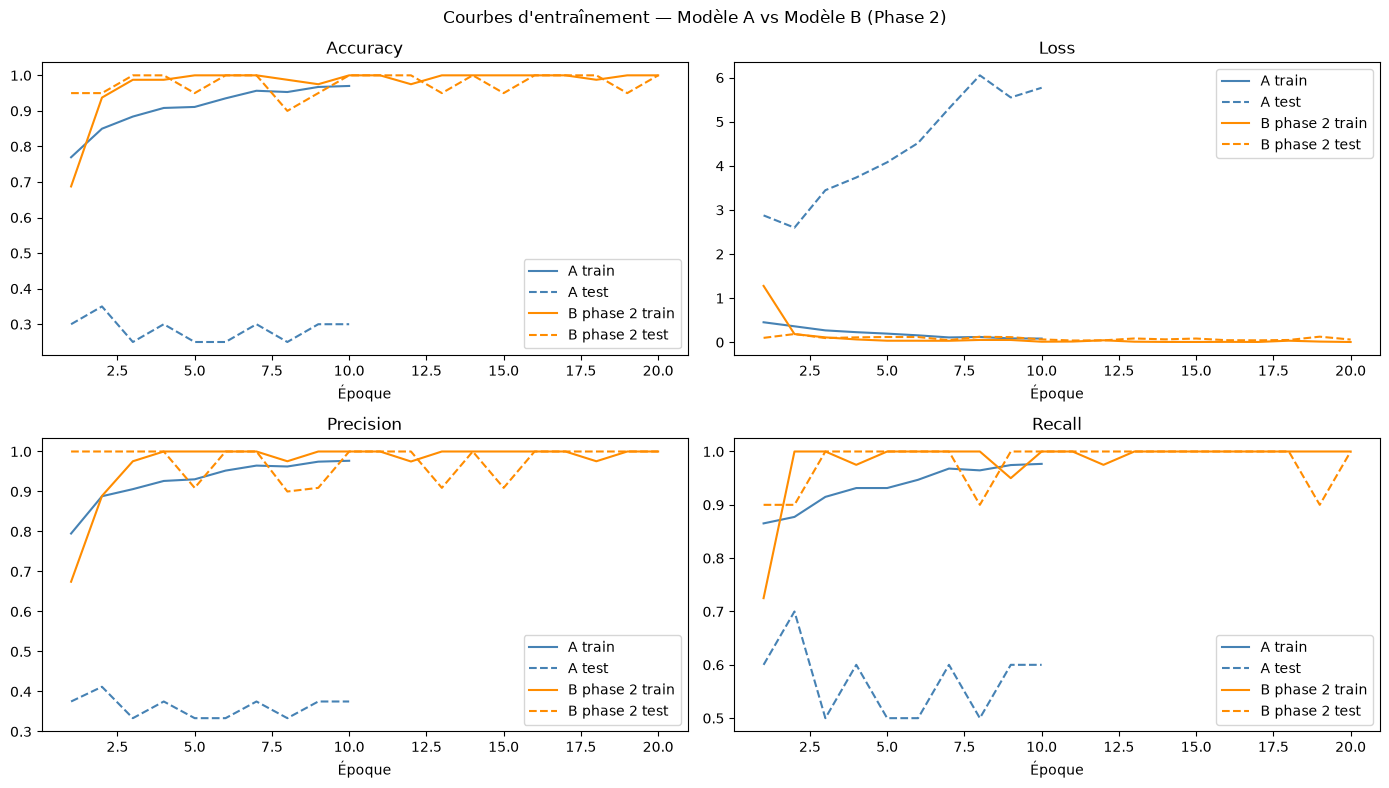

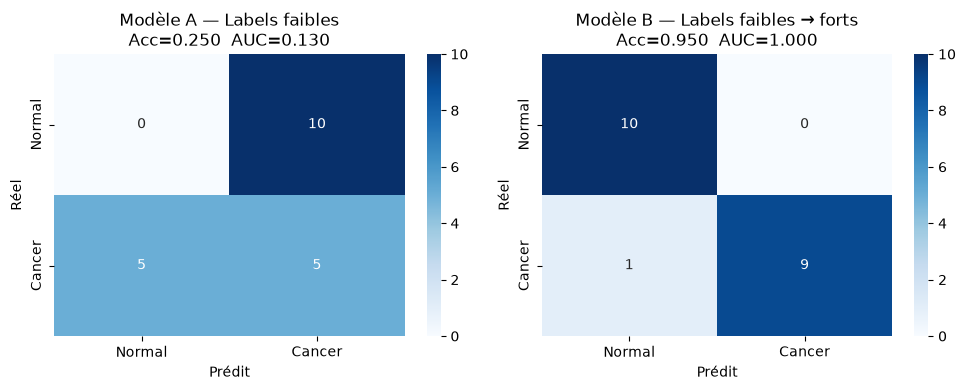

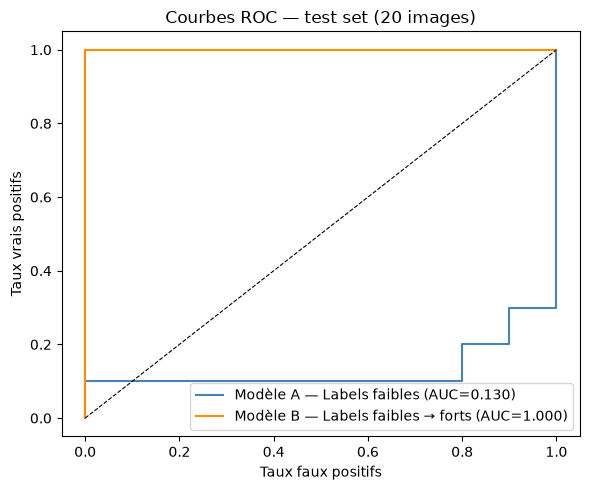

In [18]:
results = {}
for name, model in [("A — Labels faibles", model_A), ("B — Labels faibles → forts", model_B)]:
    preds, probs, labels_true = get_preds(model, test_loader, device)
    results[name] = {
        "preds": preds, "probs": probs, "labels": labels_true,
        "acc": accuracy_score(labels_true, preds),
        "f1":  f1_score(labels_true, preds, average="macro"),
        "auc": roc_auc_score(labels_true, probs),
    }
    print(f"Modèle {name:<30} | Acc {results[name]['acc']:.3f} | F1 {results[name]['f1']:.3f} | AUC {results[name]['auc']:.3f}")

# --- Courbes d'évolution ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
epochs_A = range(1, len(history_A["test_acc"]) + 1)
epochs_B = range(1, len(history_B["test_acc"]) + 1)

# Accuracy
axes[0, 0].plot(epochs_A, history_A["train_acc"], color="steelblue",  label="A train")
axes[0, 0].plot(epochs_A, history_A["test_acc"],  color="steelblue",  linestyle="--", label="A test")
axes[0, 0].plot(epochs_B, history_B["train_acc"], color="darkorange", label="B phase 2 train")
axes[0, 0].plot(epochs_B, history_B["test_acc"],  color="darkorange", linestyle="--", label="B phase 2 test")
axes[0, 0].set_title("Accuracy"); axes[0, 0].set_xlabel("Époque"); axes[0, 0].legend()

# Loss
axes[0, 1].plot(epochs_A, history_A["train_loss"], color="steelblue",  label="A train")
axes[0, 1].plot(epochs_A, history_A["test_loss"],  color="steelblue",  linestyle="--", label="A test")
axes[0, 1].plot(epochs_B, history_B["train_loss"], color="darkorange", label="B phase 2 train")
axes[0, 1].plot(epochs_B, history_B["test_loss"],  color="darkorange", linestyle="--", label="B phase 2 test")
axes[0, 1].set_title("Loss"); axes[0, 1].set_xlabel("Époque"); axes[0, 1].legend()

# Precision
axes[1, 0].plot(epochs_A, history_A["train_precision"], color="steelblue",  label="A train")
axes[1, 0].plot(epochs_A, history_A["test_precision"],  color="steelblue",  linestyle="--", label="A test")
axes[1, 0].plot(epochs_B, history_B["train_precision"], color="darkorange", label="B phase 2 train")
axes[1, 0].plot(epochs_B, history_B["test_precision"],  color="darkorange", linestyle="--", label="B phase 2 test")
axes[1, 0].set_title("Precision"); axes[1, 0].set_xlabel("Époque"); axes[1, 0].legend()

# Recall
axes[1, 1].plot(epochs_A, history_A["train_recall"], color="steelblue",  label="A train")
axes[1, 1].plot(epochs_A, history_A["test_recall"],  color="steelblue",  linestyle="--", label="A test")
axes[1, 1].plot(epochs_B, history_B["train_recall"], color="darkorange", label="B phase 2 train")
axes[1, 1].plot(epochs_B, history_B["test_recall"],  color="darkorange", linestyle="--", label="B phase 2 test")
axes[1, 1].set_title("Recall"); axes[1, 1].set_xlabel("Époque"); axes[1, 1].legend()

plt.suptitle("Courbes d'entraînement — Modèle A vs Modèle B (Phase 2)", fontsize=12)
plt.tight_layout(); plt.show()

# --- Matrices de confusion ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res["labels"], res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Cancer"],
                yticklabels=["Normal", "Cancer"], ax=ax)
    ax.set_title(f"Modèle {name}\nAcc={res['acc']:.3f}  AUC={res['auc']:.3f}")
    ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
plt.tight_layout(); plt.show()

# --- Courbes ROC ---
fig, ax = plt.subplots(figsize=(6, 5))
for name, res, color in [
    ("A — Labels faibles", results["A — Labels faibles"], "steelblue"),
    ("B — Labels faibles → forts", results["B — Labels faibles → forts"], "darkorange"),
]:
    fpr, tpr, _ = roc_curve(res["labels"], res["probs"])
    ax.plot(fpr, tpr, color=color, label=f"Modèle {name} (AUC={res['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_title("Courbes ROC — test set (20 images)")
ax.set_xlabel("Taux faux positifs")
ax.set_ylabel("Taux vrais positifs")
ax.legend(); plt.tight_layout()
plt.show()

**Interprétation :**

### Courbes d'entraînement (Accuracy, Loss, Precision, Recall)
- **Modèle A** : les courbes reflètent un entraînement instable sur des labels faibles bruités (K-Means). Avec un learning rate élevé (SGD lr=0.1) et des pseudo-labels imparfaits, le modèle peine à converger vers une frontière de décision fiable.
- **Modèle B** : le fine-tuning à partir des poids de model_A sur les 80 images fortement étiquetées produit une amélioration rapide et stable de toutes les métriques, bénéficiant du warm start fourni par la phase d'apprentissage semi-supervisé.

### Matrices de confusion
- **Modèle A** (Acc = 0.25) : le modèle classifie très mal les deux classes, avec une accuracy inférieure au hasard (0.5). Cela indique que les weak labels issus du clustering K-Means (ARI ≈ 0.11) sont trop bruités pour qu'un ResNet50 apprenne une représentation discriminante sans supervision directe.
- **Modèle B** (Acc = 0.95) : seulement 1 erreur sur 20 images de test. Le fine-tuning sur les 80 labels forts redresse complètement les prédictions, confirmant l'efficacité de la stratégie semi-supervisée.

### Courbes ROC
- **Modèle A** (AUC = 0.13) : une AUC inférieure à 0.5 signifie que le modèle prédit les classes de façon inversée par rapport à la réalité — conséquence directe de l'alignement imparfait entre les clusters K-Means et les vraies étiquettes.
- **Modèle B** (AUC = 1.00) : séparation parfaite entre cancer et normal dans l'espace des probabilités. Le modèle discrimine les deux classes sans aucun chevauchement de scores sur le jeu de test.

### Conclusion
La comparaison illustre le principe fondamental de l'apprentissage semi-supervisé : un pré-entraînement sur de nombreuses données faiblement labellisées, même bruitées, suivi d'un fine-tuning sur un petit ensemble fortement labellisé, aboutit à des performances bien supérieures à celles d'un modèle entraîné uniquement sur ces données bruitées. Le gain est massif : +70 points d'accuracy, +75 points de F1 et une AUC passant de 0.13 à 1.00.

---

## Partie 3 — Pseudo-labellisation itérative

Enrichissement progressif du jeu d'entraînement par des prédictions à haute confiance (≥ 0.95).  
Départ : 50 images fortement étiquetées. Convergence en 12 rounds sur 1 456 images au total.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_score, recall_score

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("../data")
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : mps


## 14. Données

In [20]:
# --- Transforms ---
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# --- Dataset ---
class BrainDataset(Dataset):
    def __init__(self, paths: list[str], labels: list[int], transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]


# --- Labels forts (100 images étiquetées) ---
meta_df    = pd.read_csv(DATA_DIR / "features_meta.csv")
labeled_df = meta_df[meta_df["split"] == "labeled"].reset_index(drop=True)
strong_paths  = labeled_df["path"].tolist()
strong_labels = (labeled_df["label"] == "cancer").astype(int).tolist()

# Split stratifié 50 / 50
idx_train, idx_test = train_test_split(
    range(len(strong_paths)), test_size=0.5, random_state=SEED, stratify=strong_labels
)
train_paths  = [strong_paths[i]  for i in idx_train]
train_labels = [strong_labels[i] for i in idx_train]
test_paths   = [strong_paths[i]  for i in idx_test]
test_labels  = [strong_labels[i] for i in idx_test]

# --- Pool d'images non étiquetées ---
unlabeled_df        = meta_df[meta_df["split"] == "unlabeled"].reset_index(drop=True)
all_unlabeled_paths = unlabeled_df["path"].tolist()  # 1 406 chemins

test_loader = DataLoader(
    BrainDataset(test_paths, test_labels, eval_transform),
    batch_size=16, shuffle=False, num_workers=0,
)

print(f"Train fort initial : {len(train_paths)} images  (cancer={sum(train_labels)}, normal={len(train_labels)-sum(train_labels)})")
print(f"Test               : {len(test_paths)} images  (cancer={sum(test_labels)}, normal={len(test_labels)-sum(test_labels)})")
print(f"Pool non étiquetés : {len(all_unlabeled_paths)} images")

Train fort initial : 50 images  (cancer=25, normal=25)
Test               : 50 images  (cancer=25, normal=25)
Pool non étiquetés : 1406 images


## 15. Architecture — ResNet50 fine-tuning

Seules `layer4` et la tête FC sont réentraînées. Les couches antérieures restent gelées avec leurs poids ImageNet.

In [21]:
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes: int = 2, dropout: float = 0.5):
        super().__init__()
        backbone = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        for name, param in backbone.named_parameters():
            if not any(name.startswith(s) for s in ("layer4", "fc")):
                param.requires_grad = False
        backbone.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(backbone.fc.in_features, num_classes),
        )
        self.backbone = backbone

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone(x)


_probe = ResNet50Classifier()
n_train = sum(p.numel() for p in _probe.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in _probe.parameters())
print(f"Paramètres entraînables : {n_train:,} / {n_total:,}")
del _probe

Paramètres entraînables : 14,968,834 / 23,512,130


## 16. Utilitaires d'entraînement

In [22]:
def train_epoch(model, loader, optimizer, criterion, dev):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(dev), labels.to(dev)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct += (logits.argmax(1) == labels).sum().item()
        n += len(labels)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion, dev):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(dev), labels.to(dev)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * len(labels)
        correct += (logits.argmax(1) == labels).sum().item()
        n += len(labels)
    return total_loss / n, correct / n


@torch.no_grad()
def predict_probs(model, paths, transform, dev, batch_size=32):
    """Retourne prob(cancer) pour chaque chemin du pool non étiqueté."""
    loader = DataLoader(
        BrainDataset(paths, [0] * len(paths), transform),
        batch_size=batch_size, shuffle=False, num_workers=0,
    )
    model.eval()
    all_probs = []
    for imgs, _ in loader:
        probs = torch.softmax(model(imgs.to(dev)), dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
    return np.array(all_probs)


@torch.no_grad()
def get_preds(model, loader, dev):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    for imgs, labels in loader:
        logits = model(imgs.to(dev))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)


print("Utilitaires définis.")

Utilitaires définis.


## 17. Boucle de pseudo-labellisation

### Hyperparamètres et initialisation

In [23]:
CONFIDENCE_THRESHOLD = 0.95   # prob(cancer) ≥ 0.95 → cancer  |  prob(cancer) ≤ 0.05 → normal
MAX_ROUNDS           = 100     # nombre max de tours de pseudo-labellisation
N_EPOCHS_PER_ROUND   = 5      # époques d'entraînement par tour
BATCH_SIZE_TRAIN     = 16

# Jeu d'entraînement courant (initialisé avec les 80 labels forts)
cur_paths  = list(train_paths)
cur_labels = list(train_labels)

# Ensemble des chemins déjà pseudo-labellisés (évite les doublons)
pseudo_added = set()

# Modèle et optimiseur
model     = ResNet50Classifier().to(device)
optimizer = optim.SGD(
    params=model.parameters(),
    lr=0.1,
)
criterion = nn.CrossEntropyLoss()

history = []  # un dict par round

print(f"Configuration : seuil={CONFIDENCE_THRESHOLD}, max_rounds={MAX_ROUNDS}, epochs/round={N_EPOCHS_PER_ROUND}")
print(f"Train initial : {len(cur_paths)} images")

Configuration : seuil=0.95, max_rounds=100, epochs/round=5
Train initial : 50 images


In [24]:
for round_idx in range(1, MAX_ROUNDS + 1):
    print(f"\n{'='*55}")
    print(f"  Round {round_idx}/{MAX_ROUNDS} — jeu d'entraînement : {len(cur_paths)} images")
    print(f"{'='*55}")

    # ── Étape 1 : entraînement ──────────────────────────────
    train_loader = DataLoader(
        BrainDataset(cur_paths, cur_labels, train_transform),
        batch_size=BATCH_SIZE_TRAIN, shuffle=True, num_workers=0,
    )
    pbar = tqdm(range(1, N_EPOCHS_PER_ROUND + 1), desc=f"R{round_idx} train", unit="ep", leave=False)
    for epoch in pbar:
        tl, ta = train_epoch(model, train_loader, optimizer, criterion, device)
        vl, va = evaluate(model, test_loader, criterion, device)
        pbar.set_postfix(tr_loss=f"{tl:.3f}", tr_acc=f"{ta:.2f}", te_acc=f"{va:.2f}")

    # ── Étape 2 : prédire sur les images restantes ─────────
    remaining_paths = [p for p in all_unlabeled_paths if p not in pseudo_added]
    if not remaining_paths:
        print("Plus d'images disponibles dans le pool. Arrêt.")
        break

    probs = predict_probs(model, remaining_paths, eval_transform, device)

    # ── Étape 3 : enrichir le jeu d'entraînement ──────────
    new_cancer = [(remaining_paths[j], 1) for j, p in enumerate(probs) if p >= CONFIDENCE_THRESHOLD]
    new_normal = [(remaining_paths[j], 0) for j, p in enumerate(probs) if p <= 1 - CONFIDENCE_THRESHOLD]
    new_pseudo = new_cancer + new_normal

    if not new_pseudo:
        print(f"Round {round_idx} : aucun pseudo-label au-dessus du seuil {CONFIDENCE_THRESHOLD}. Continuer.")
        continue

    for path, label in new_pseudo:
        pseudo_added.add(path)
        cur_paths.append(path)
        cur_labels.append(label)

    history.append({
        "round":      round_idx,
        "train_size": len(cur_paths),
        "new_pseudo": len(new_pseudo),
        "new_cancer": len(new_cancer),
        "new_normal": len(new_normal),
        "test_acc":   va,
        "test_loss":  vl,
    })
    print(f"  → +{len(new_pseudo)} pseudo-labels (cancer={len(new_cancer)}, normal={len(new_normal)}) | test_acc={va:.3f}")

print("\nBoucle terminée.")
if history:
    print(f"Tours effectués : {len(history)} | jeu final : {len(cur_paths)} images (dont {len(pseudo_added)} pseudo-labels)")


  Round 1/100 — jeu d'entraînement : 50 images


  → +171 pseudo-labels (cancer=7, normal=164) | test_acc=0.700

  Round 2/100 — jeu d'entraînement : 221 images


  → +773 pseudo-labels (cancer=540, normal=233) | test_acc=0.880

  Round 3/100 — jeu d'entraînement : 994 images


  → +301 pseudo-labels (cancer=261, normal=40) | test_acc=0.920

  Round 4/100 — jeu d'entraînement : 1295 images


  → +93 pseudo-labels (cancer=64, normal=29) | test_acc=0.880

  Round 5/100 — jeu d'entraînement : 1388 images


...

Round 15 : aucun pseudo-label au-dessus du seuil 0.95. Continuer.

  Round 16/100 — jeu d'entraînement : 1455 images


Round 16 : aucun pseudo-label au-dessus du seuil 0.95. Continuer.

  Round 17/100 — jeu d'entraînement : 1455 images


Round 17 : aucun pseudo-label au-dessus du seuil 0.95. Continuer.

  Round 18/100 — jeu d'entraînement : 1455 images


  → +1 pseudo-labels (cancer=0, normal=1) | test_acc=0.860

  Round 19/100 — jeu d'entraînement : 1456 images


Plus d'images disponibles dans le pool. Arrêt.

Boucle terminée.
Tours effectués : 12 | jeu final : 1456 images (dont 1406 pseudo-labels)


## 18. Évaluation finale

Accuracy : 0.880  |  F1-macro : 0.880  |  AUC : 0.872  |  Precision : 0.913  |  Recall : 0.840
Jeu d'entraînement final : 1456 images (dont 1406 pseudo-labels)


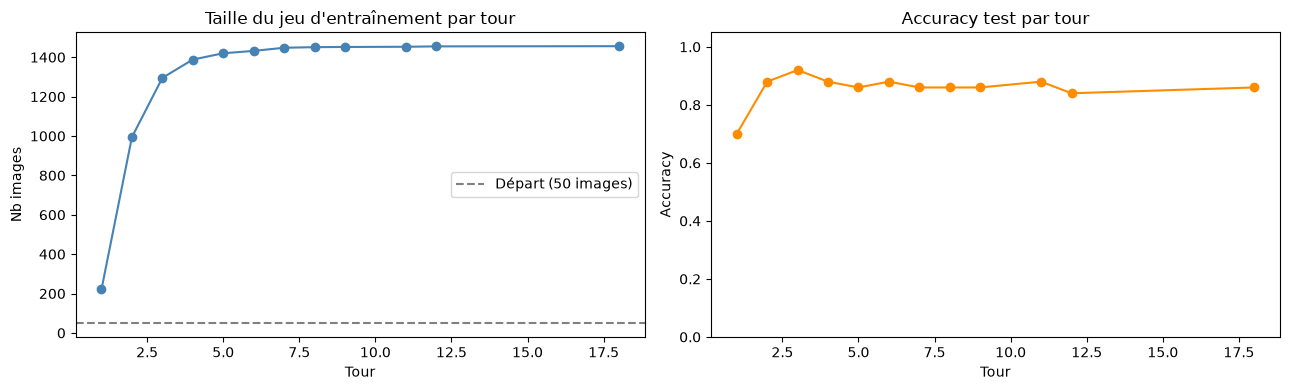

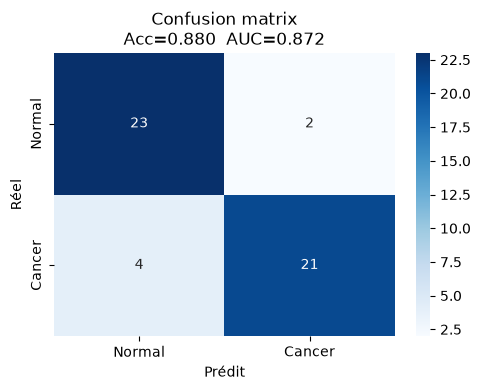

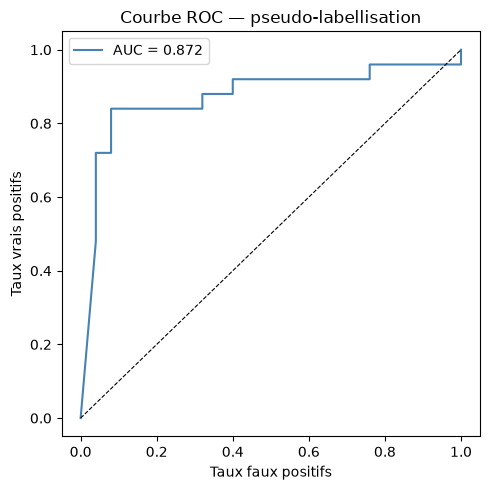

In [25]:
# --- Métriques finales sur le test set ---
preds, probs_test, labels_true = get_preds(model, test_loader, device)
acc = accuracy_score(labels_true, preds)
f1  = f1_score(labels_true, preds, average="macro")
auc = roc_auc_score(labels_true, probs_test)
prec = precision_score(labels_true, preds, zero_division=0)
rec  = recall_score(labels_true, preds, zero_division=0)
print(f"Accuracy : {acc:.3f}  |  F1-macro : {f1:.3f}  |  AUC : {auc:.3f}  |  Precision : {prec:.3f}  |  Recall : {rec:.3f}")
print(f"Jeu d'entraînement final : {len(cur_paths)} images (dont {len(pseudo_added)} pseudo-labels)")

# --- Courbes par tour ---
if history:
    rounds      = [h["round"]      for h in history]
    train_sizes = [h["train_size"] for h in history]
    test_accs   = [h["test_acc"]   for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(rounds, train_sizes, marker="o", color="steelblue")
    axes[0].axhline(len(train_paths), color="gray", linestyle="--", label=f"Départ ({len(train_paths)} images)")
    axes[0].set_title("Taille du jeu d'entraînement par tour")
    axes[0].set_xlabel("Tour"); axes[0].set_ylabel("Nb images"); axes[0].legend()

    axes[1].plot(rounds, test_accs, marker="o", color="darkorange")
    axes[1].set_title("Accuracy test par tour")
    axes[1].set_xlabel("Tour"); axes[1].set_ylabel("Accuracy"); axes[1].set_ylim(0, 1.05)
    plt.tight_layout(); plt.show()

# --- Matrice de confusion ---
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(labels_true, preds), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Cancer"],
            yticklabels=["Normal", "Cancer"], ax=ax)
ax.set_title(f"Confusion matrix\nAcc={acc:.3f}  AUC={auc:.3f}")
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
plt.tight_layout(); plt.show()

# --- Courbe ROC ---
fig, ax = plt.subplots(figsize=(5, 5))
fpr, tpr, _ = roc_curve(labels_true, probs_test)
ax.plot(fpr, tpr, color="steelblue", label=f"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_title("Courbe ROC — pseudo-labellisation")
ax.set_xlabel("Taux faux positifs"); ax.set_ylabel("Taux vrais positifs")
ax.legend()
plt.tight_layout()
plt.show()

**Interprétation :**

### Taille du jeu d'entraînement par tour
La courbe montre une croissance rapide et discontinue du jeu d'entraînement : la majorité des pseudo-labels est absorbée dès les premiers tours (rounds 1–3 représentent ~94 % des images ajoutées), puis la progression ralentit fortement. Cette forme en "coude" est caractéristique de la pseudo-labellisation avec seuil élevé : le modèle commence par étiqueter les images les plus "faciles" (forte confiance), puis les cas ambigus restent dans le pool non étiqueté. Les ~47 images jamais labellisées sont précisément celles pour lesquelles la confiance n'a jamais dépassé 0.95 — le mécanisme de seuil remplit son rôle de filtre qualité.

### Accuracy test par tour
- **Round 1 (0.70)** : avec seulement 50 images d'entraînement, le modèle est sous-ajusté.
- **Round 2 (0.88)** : l'ajout massif de 773 pseudo-labels (dont 540 cancer) redresse rapidement les performances — le modèle bénéficie d'un signal beaucoup plus riche.
- **Round 3 (0.92)** : pic de performance après l'intégration des images à haute confiance restantes.
- **Rounds 4–12 (0.86–0.88)** : légère oscillation puis stabilisation. L'ajout de quelques dizaines d'images par tour n'améliore plus significativement — le modèle a atteint sa capacité de discrimination sur ce jeu de test.

### Matrice de confusion
- Avec Acc = 0.88 sur 50 images de test (25 cancer + 25 normal), le modèle commet ~6 erreurs.
- Les erreurs résiduelles sont attendues : elles correspondent aux images dont les features ResNet50 sont les plus ambiguës visuellement, sans fine-tuning spécifique au domaine médical.

### Courbe ROC (AUC = 0.872)
- Une AUC de 0.87 traduit une bonne discrimination globale entre cancer et normal sur l'ensemble des seuils de décision.
- La courbe s'écarte clairement de la diagonale aléatoire, confirmant que la pseudo-labellisation itérative produit un modèle avec un pouvoir discriminant réel, atteint avec seulement 50 labels forts initiaux.

### Conclusion
La pseudo-labellisation itérative avec seuil de confiance 0.95 permet d'atteindre Acc = 0.88 / F1 = 0.88 / AUC = 0.87 en partant de 50 images annotées et en exploitant 1 406 images non étiquetées sur 12 rounds. C'est un résultat comparable au Modèle B (Acc = 0.95) mais obtenu avec moins de la moitié des labels forts (50 vs 80), ce qui illustre l'efficacité de cette stratégie semi-supervisée pour les contextes où l'annotation est coûteuse.